In [1]:
# %%
import numpy as np
from matplotlib import pyplot as plt
import csv

# %matplotlib inline

import xarray as xr
import lib_ecofun as lef

from scipy.optimize import curve_fit, minimize, dual_annealing, basinhopping, brute, differential_evolution, shgo, direct


In [2]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

In [3]:
gdp = lef.read_gdp_owid()
gdp2 = lef.gdp

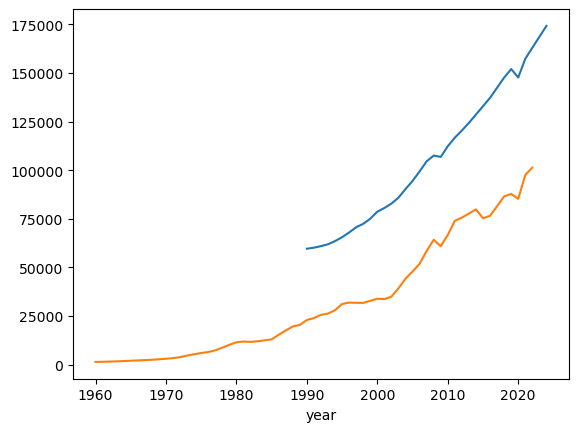

In [10]:
gdp.plot()
gdp2.plot()

In [14]:
allobs = lef.define_obs(None, adimensional=True)

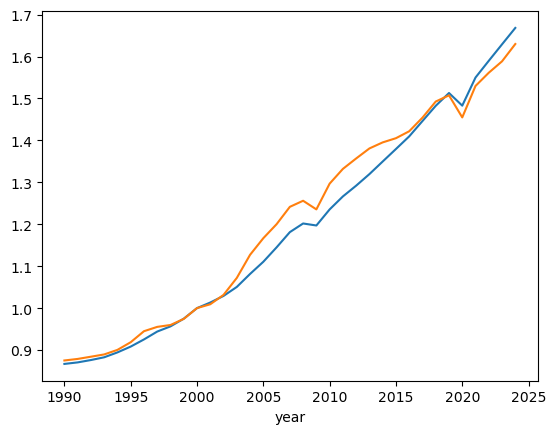

In [21]:
(0.45 + 0.55*gdp/gdp.sel(year=2000)).plot()
(allobs['E']).sel(year = slice(1990, None)).plot()

In [4]:
# %%
year_ini = 2000
params = lef.default_params.copy()

verbose = False

public_investment = False

params['r_inv_state'] = 0.015
arr = np.concatenate([np.linspace(0., 0.7, 20), np.linspace(0.7, 0.7, 80)])
mu_scen = xr.DataArray(arr, dims = ('year'), coords = {'year': np.arange(year_ini, year_ini + 100)})

obs_weights = None

result_dict = {}

In [5]:
params

{'growth': 0.01,
 'eps': 1,
 'a': 1,
 'b': 1,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': 0.2,
 'eta_f': 0.2,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.1,
 'beta_0': 0.2,
 'delta_sig': 0.5,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [6]:
params['a'] = 2.3
params['b'] = 1.4

In [7]:
params_prime = params.copy()

params_prime['a'] = lef.a_prime(year_ini, a = params['a'])
params_prime['b'] = lef.a_prime(year_ini, a = params['b'])

In [8]:
params_prime

{'growth': 0.01,
 'eps': 1,
 'a': 0.7061236460320618,
 'b': 0.4298143932369072,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': 0.2,
 'eta_f': 0.2,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.1,
 'beta_0': 0.2,
 'delta_sig': 0.5,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [8]:
# # assuming a increases after 2010
# a_scen = xr.DataArray(8*[0.1] + list(np.linspace(0.1, 0.7, 7)) + 85 * [params_prime['a']], dims = ["year"], coords = {"year": np.arange(2000, 2100)})
# a_scen.plot()
# params_prime['a'] = a_scen

In [9]:
params_prime_range = {
 'growth': (0.01, 0.05),
 'delta_sig': (0.2, 1.),
 'a': (0.6, 1.1),
 'b': (0.3, 0.8),
 'gamma_f': (0.1, 0.7),
 'gamma_g': (0.1, 0.7),
 'eta_g': (0.1, 0.95),
 'eta_f': (0.1, 0.95),
 'r_inv': (0.05, 0.5),
 'beta_0': (-0.5, 0.5)}

In [10]:
inicond = lef.inicond_yr(year_ini, params_prime, adimensional = True, fcu = lef.fossil_capacity_util)

In [11]:
inicond

{'Y_ini': 1.0,
 'Eg_ini': 0.07825325742181562,
 'Ef_ini': 0.9217467425781845,
 'E_ini': 1.0,
 'Kf_ini': 2.6806534316957236,
 'Kg_ini': 0.11082089923138264}

In [108]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

# TEST!

In [12]:
obs2 = lef.define_obs(['E', 'Eg_ratio', 'Ig_ratio'], year_ref = year_ini)
obs_weights2 = {'E': 1, 'Eg_ratio': 100, 'Ig_ratio': 1}

In [14]:
#parnames = ['growth', 'delta_sig', 'beta_0', 'r_inv', 'a', 'b', 'gamma_g']#, 'eta_g', 'gamma_g']
parnames = ['growth', 'delta_sig', 'beta_0', 'r_inv', 'a', 'b', 'gamma_g', 'eta_g']
same_costs = True
bounds = [params_prime_range[par] for par in parnames]

In [17]:
params_fit = params_prime.copy()
params_fit['eta_g'] = 0.2
params_fit['eta_f'] = 0.2
params_fit['eps'] = 0.33
scale_costs = True
same_price = True
recalc_inicond = True

inicond_recalc = inicond.copy()

In [ ]:
resu = dual_annealing(lef.cost_function, bounds, args = (parnames, params_fit, year_ini, inicond_recalc, verbose, obs2, obs_weights2, public_investment, mu_scen, same_costs, scale_costs, same_price, recalc_inicond))
print(f'AAAAAAAAAAAAAAA dual: {resu.fun:5.2f}  ', resu.x)

Recalculating inicond based on new parameters...
Too short! extending up to 2025
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Too short! extending up to 2025
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Too short! extending up to 2025
Recalculating inicond based on new parameters...
Too short! extending up to 2025
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Recalculating inicond based on new parameters...
Too short! extending up to 2025
Recalcu

In [15]:
res = [ 0.04915769,  0.45334301, -0.06433923,  0.09749707,  0.75145398,  0.6131497,
  0.65809501,  0.25176405]

In [18]:
for par, parval in zip(parnames, res):#resu.x):
    params_fit[par] = parval
    
if same_price: params_fit['gamma_f'] = params_fit['gamma_g']
if same_costs: params_fit['eta_f'] = params_fit['eta_g']

inicond_recalc = lef.inicond_yr(year_ini, params_fit, adimensional = True, fcu = lef.fossil_capacity_util)

resu_new = lef.run_model(inicond = inicond_recalc, params = params_fit, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=scale_costs)

params:  {'growth': 0.04915769, 'eps': 0.33, 'a': 0.75145398, 'b': 0.6131497, 'gamma_f': 0.65809501, 'gamma_g': 0.65809501, 'eta_g': 0.25176405, 'eta_f': 0.25176405, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.09749707, 'beta_0': -0.06433923, 'delta_sig': 0.45334301, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.06     -0.66      0.08      0.92      0.01      0.45      0.00      0.04
params:  {'growth': 0.04915769, 'eps': 0.33, 'a': 0.75145398, 'b': 0.6131497, 'gamma_f': 0.65809501, 'gamma_g': 0.65809501, 'eta_g': 0.25176405, 'eta_f': 0.25176405, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.09749707, 'beta_0': -0.06433923, 'delta_sig': 0.45334301, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.06     -0.64      0.08      0.94      0.01      0.46      0.00      0.04
params:  {'growth': 0.04915769, 'eps': 0.33, 'a': 0.75145398, 'b': 0.6131497, 'gamma_f': 0.65809501, 'gamma_g': 0.65809501, 'eta_g': 0.25176405, 'eta_f': 0.251764

In [19]:
obs_weights2['Eg_ratio'] = 10

In [20]:
lef.costfun(resu_new, obs2, obs_weights2)

100.0

In [21]:
resu_new

<xarray.Dataset>
Dimensions:   (year: 30)
Coordinates:
  * year      (year) int64 2000 2001 2002 2003 2004 ... 2025 2026 2027 2028 2029
Data variables: (12/14)
    Y         (year) float64 1.049 1.101 1.155 1.212 ... 3.653 3.833 4.021 4.219
    Kg        (year) float64 0.1056 0.1072 0.1091 ... 0.4501 0.4819 0.5151
    Kf        (year) float64 1.902 1.925 1.949 1.973 ... 2.585 2.616 2.648 2.681
    E         (year) float64 1.0 1.016 1.033 1.051 ... 1.819 1.876 1.935 1.997
    Eg        (year) float64 0.07825 0.07933 0.08056 ... 0.3154 0.3382 0.3621
    Ef        (year) float64 0.9217 0.9369 0.9527 0.9691 ... 1.56 1.597 1.635
    ...        ...
    Pg        (year) float64 0.00515 0.00554 0.00599 ... 0.1145 0.1262 0.1386
    Pf        (year) float64 0.4475 0.4562 0.4652 ... 0.8198 0.8414 0.8641
    Ig_ratio  (year) float64 0.05601 0.05989 0.06436 ... 0.3792 0.3848 0.3894
    Eg_ratio  (year) float64 0.07825 0.07806 0.07797 ... 0.1682 0.1748 0.1813
    Cg        (year) float64 0.07043 0.07091 0.07146 ... 0.1414 0.1464 0.1515
    Cf        (year) float64 0.2417 0.2437 0.2457 ... 0.3145 0.3181 0.3219
Attributes:
    success:      False
    transition:   False
    year_zero:    nan
    year_peak:    nan
    year_halved:  nan

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

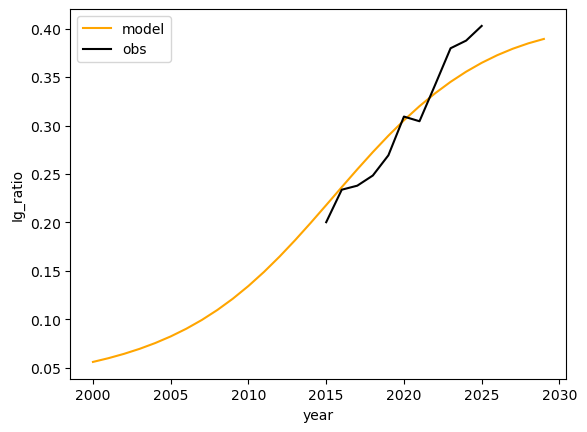

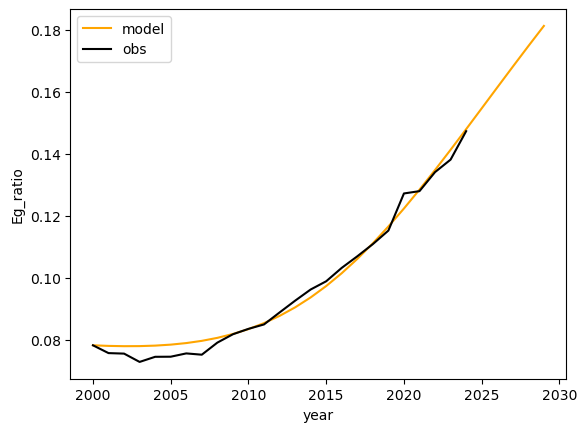

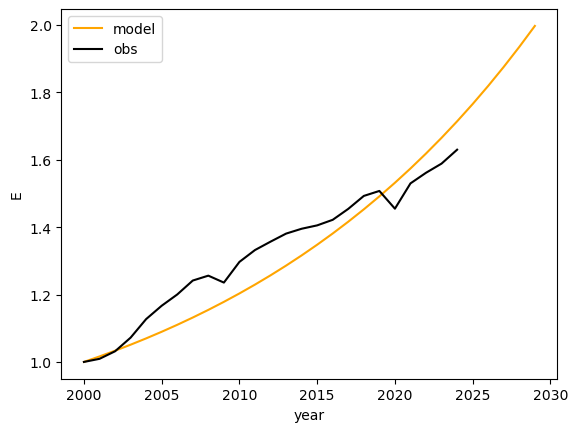

In [22]:
lef.plot_resuvsobs_ds(resu_new, obs2)

In [ ]:
resu_hist = lef.run_model(inicond = inicond_recalc, params = params_fit, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=scale_costs)

In [1]:
reload(lef)

NameError: name 'reload' is not defined

In [24]:
gdp_scen = lef.read_gdp_scenarios()

(0.0, 200000.0)

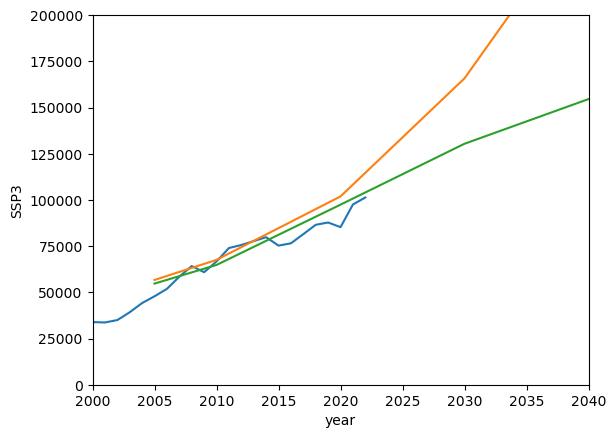

In [40]:
lef.gdp.plot()
gdp_scen.SSP5.plot()
gdp_scen.SSP3.plot()
plt.xlim(2000, 2040)
plt.ylim(0, 2e5)

In [110]:
from scipy.optimize import curve_fit

def fit_piecewise(da: xr.DataArray, breakpoint_year: int = None) -> dict:
    """
    Fit a two-slope piecewise linear function with bias to a DataArray with 'year' dimension.
    
    f(year) = c + m1*(year - bp)        if year <= breakpoint
              c + m2*(year - bp)        if year >  breakpoint
    """
    years = da.year.values.astype(float)
    values = da.values.astype(float)
    
    if breakpoint_year is None:
        breakpoint_year = int(years[len(years) // 2])
    
    def model(year, m1, m2, c):
        return c + np.where(
            year <= breakpoint_year,
            m1 * (year - breakpoint_year),
            m2 * (year - breakpoint_year)
        )
    
    overall_slope = (values[-1] - values[0]) / (years[-1] - years[0])
    anchor = float(da.sel(year=breakpoint_year))
    p0 = [overall_slope, overall_slope, anchor]
    
    popt, pcov = curve_fit(model, years, values, p0=p0)
    m1, m2, c = popt
    
    fitted_values = model(years, m1, m2, c)
    fitted_da = xr.DataArray(fitted_values, coords={"year": da.year}, dims="year")
    
    return {
        "m1": m1,
        "m2": m2,
        "c": c,
        "breakpoint_year": breakpoint_year,
        "fitted": fitted_da,
        "perr": np.sqrt(np.diag(pcov))
    }

In [15]:
ok_gdp = lef.gdp.sel(year = slice(2000, None))

In [52]:
ok_gdp

<xarray.DataArray (year: 23)>
array([ 33898.96936412,  33689.21160517,  34982.49443624,  39219.22835228,
        44195.41873342,  47859.24304084,  51862.62193646,  58446.78438498,
        64227.64549587,  60885.97098376,  66707.07176466,  73965.14117739,
        75612.54877317,  77714.72386794,  79837.15682513,  75283.27055183,
        76518.97897363,  81484.10107146,  86542.67817903,  87777.40395632,
        85257.73734991,  97529.67680742, 101325.68672463])
Coordinates:
  * year     (year) int64 2000 2001 2002 2003 2004 ... 2018 2019 2020 2021 2022

In [13]:
def model(year, m1, m2, c, breakpoint_year):
    return c + np.where(
        year <= breakpoint_year,
        m1 * (year - breakpoint_year),
        m2 * (year - breakpoint_year)
    )

In [113]:
fit_piecewise(ok_gdp, breakpoint_year= 2010)

{'m1': 3809.360024336776,
 'm2': 2313.15023071385,
 'c': 67996.21082255931,
 'breakpoint_year': 2010,
 'fitted': <xarray.DataArray (year: 23)>
 array([29902.61057919, 33711.97060353, 37521.33062787, 41330.6906522 ,
        45140.05067654, 48949.41070088, 52758.77072521, 56568.13074955,
        60377.49077389, 64186.85079822, 67996.21082256, 70309.36105327,
        72622.51128399, 74935.6615147 , 77248.81174541, 79561.96197613,
        81875.11220684, 84188.26243756, 86501.41266827, 88814.56289898,
        91127.7131297 , 93440.86336041, 95754.01359113])
 Coordinates:
   * year     (year) int64 2000 2001 2002 2003 2004 ... 2018 2019 2020 2021 2022,
 'perr': array([ 268.30325453,  217.56866647, 1425.44058184])}

In [48]:
spezzata = model(ok_gdp.year, 3809.4, 2313.15, c = 67996.2, breakpoint_year=2010)

gdp_fit = xr.DataArray(spezzata, coords={"year": ok_gdp.year}, dims="year")

In [49]:
gdp_fit

<xarray.DataArray (year: 23)>
array([29902.2 , 33711.6 , 37521.  , 41330.4 , 45139.8 , 48949.2 ,
       52758.6 , 56568.  , 60377.4 , 64186.8 , 67996.2 , 70309.35,
       72622.5 , 74935.65, 77248.8 , 79561.95, 81875.1 , 84188.25,
       86501.4 , 88814.55, 91127.7 , 93440.85, 95754.  ])
Coordinates:
  * year     (year) int64 2000 2001 2002 2003 2004 ... 2018 2019 2020 2021 2022

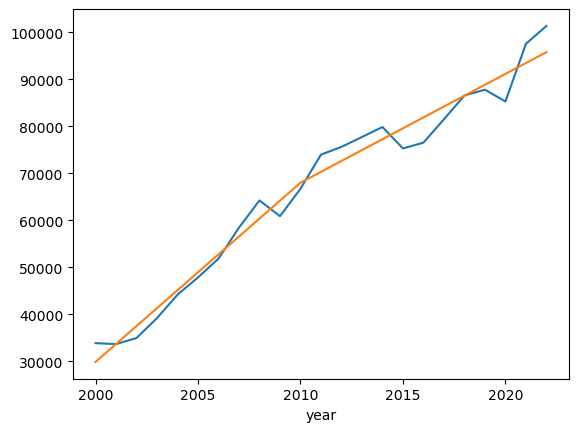

In [115]:
ok_gdp.plot()
plt.plot(ok_gdp.year, model(ok_gdp.year, 3809.4, 2313.15, c = 67996.2, breakpoint_year=2010))

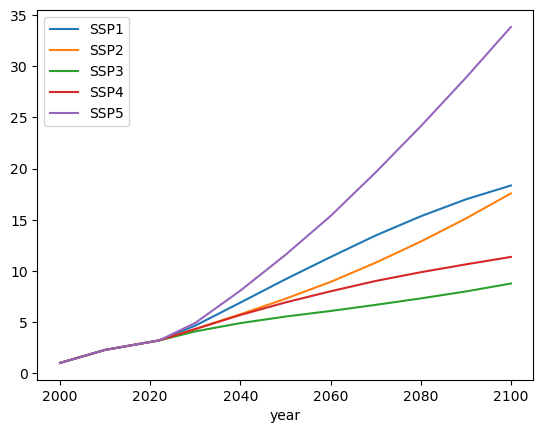

In [119]:
all_scen = []

for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    mismatch = gdp_scen[ssp].sel(year = 2022) - gdp_fit.sel(year = 2022)

    fitto = xr.concat([gdp_fit, gdp_scen[ssp].sel(year = slice(2023, None))-mismatch.values], dim = 'year')
    (fitto/fitto.sel(year = 2000)).plot(label = ssp)

    all_scen.append(fitto/fitto.sel(year = 2000))

plt.legend()

In [27]:
gdp_scen

<xarray.Dataset>
Dimensions:  (year: 96)
Coordinates:
  * year     (year) int64 2005 2006 2007 2008 2009 ... 2096 2097 2098 2099 2100
Data variables:
    SSP1     (year) float64 5.741e+13 5.962e+13 ... 5.613e+14 5.654e+14
    SSP2     (year) float64 5.653e+13 5.873e+13 6.093e+13 ... 5.32e+14 5.393e+14
    SSP3     (year) float64 5.473e+13 5.675e+13 ... 2.679e+14 2.703e+14
    SSP4     (year) float64 5.671e+13 5.876e+13 6.08e+13 ... 3.499e+14 3.521e+14
    SSP5     (year) float64 5.669e+13 5.887e+13 ... 1.016e+15 1.031e+15

In [121]:
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

In [82]:
resu_all = []
for scen in all_scen:
    res = lef.run_model(inicond = inicond_recalc, params = params_fit, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=scale_costs, gdp_type='custom', gdp_scenario=scen)
    resu_all.append(res)

params:  {'growth': 0.04915769, 'eps': 0.33, 'a': 0.75145398, 'b': 0.6131497, 'gamma_f': 0.65809501, 'gamma_g': 0.65809501, 'eta_g': 0.25176405, 'eta_f': 0.25176405, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.09749707, 'beta_0': -0.06433923, 'delta_sig': 0.45334301, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.06     -0.66      0.08      0.92      0.01      0.45      0.00      0.04
params:  {'growth': 0.04915769, 'eps': 0.33, 'a': 0.75145398, 'b': 0.6131497, 'gamma_f': 0.65809501, 'gamma_g': 0.65809501, 'eta_g': 0.25176405, 'eta_f': 0.25176405, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.09749707, 'beta_0': -0.06433923, 'delta_sig': 0.45334301, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.06     -0.63      0.08      0.92      0.01      0.45      0.00      0.04
params:  {'growth': 0.04915769, 'eps': 0.33, 'a': 0.75145398, 'b': 0.6131497, 'gamma_f': 0.65809501, 'gamma_g': 0.65809501, 'eta_g': 0.25176405, 'eta_f': 0.251764

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

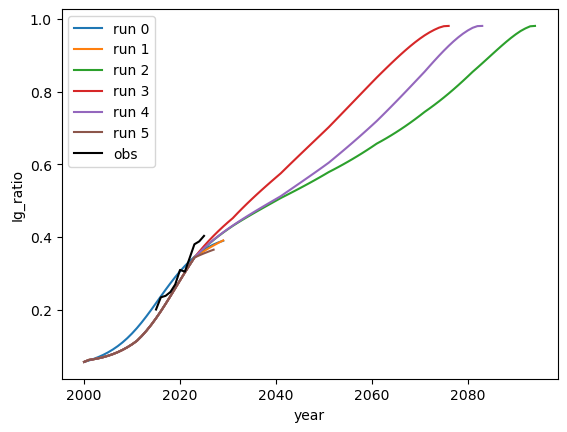

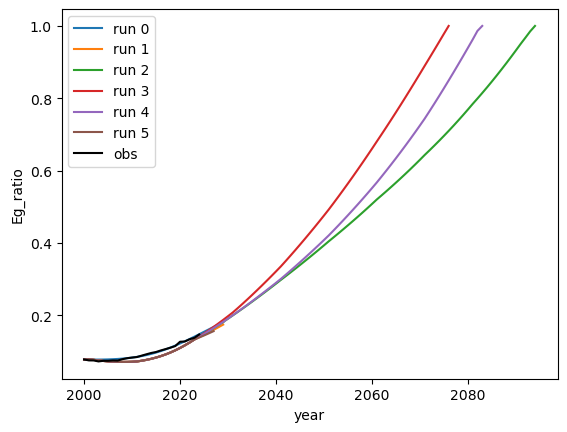

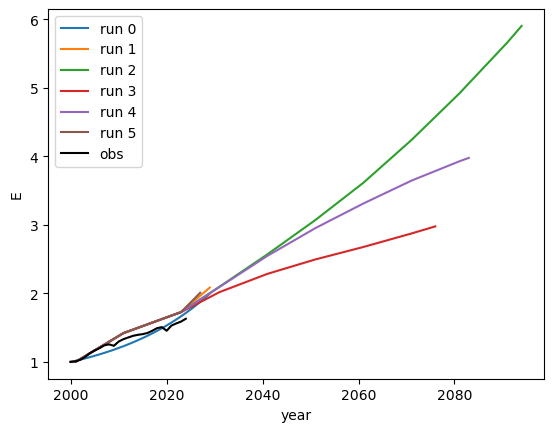

In [83]:
lef.plot_resuvsobs_ds([resu_new] + resu_all, obs2, year_ok = slice(2000, 2100))

### FIT with Y scenario

In [17]:
obs2 = lef.define_obs(['E', 'Eg_ratio', 'Ig_ratio'], year_ref = year_ini)
obs_weights2 = {'E': 1, 'Eg_ratio': 10, 'Ig_ratio': 1}

In [18]:
#parnames = ['growth', 'delta_sig', 'beta_0', 'r_inv', 'a', 'b', 'gamma_g']#, 'eta_g', 'gamma_g']
parnames = ['eps', 'delta_sig', 'beta_0', 'r_inv', 'a', 'b', 'gamma_g', 'eta_g']
same_costs = True
params_prime_range['eps'] = (0.2, 0.6)
bounds = [params_prime_range[par] for par in parnames]

In [19]:
params_fit = params_prime.copy()
params_fit['eta_g'] = 0.2
params_fit['eta_f'] = 0.2
params_fit['eps'] = 0.33
scale_costs = True
same_price = True
recalc_inicond = True

inicond_recalc = inicond.copy()

In [137]:
scen = all_scen[1] # SSP2
resu = dual_annealing(lef.cost_function, bounds, args = (parnames, params_fit, year_ini, inicond_recalc, verbose, obs2, obs_weights2, public_investment, mu_scen, same_costs, scale_costs, same_price, recalc_inicond, None, 'custom', scen))
print(f'AAAAAAAAAAAAAAA dual: {resu.fun:5.2f}  ', resu.x)

Cost:  0.15001563575036553 params:  {'growth': 0.01, 'eps': 0.2705364584539493, 'a': 0.8393761272665891, 'b': 0.5539394789062605, 'gamma_f': 0.5307562170907933, 'gamma_g': 0.5307562170907933, 'eta_g': 0.2940756071764507, 'eta_f': 0.2940756071764507, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.22724614094712128, 'beta_0': -0.47964470037514967, 'delta_sig': 0.648008686879091, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
Cost:  0.15001565755579083 params:  {'growth': 0.01, 'eps': 0.2705364684539493, 'a': 0.8393761272665891, 'b': 0.5539394789062605, 'gamma_f': 0.5307562170907933, 'gamma_g': 0.5307562170907933, 'eta_g': 0.2940756071764507, 'eta_f': 0.2940756071764507, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.22724614094712128, 'beta_0': -0.47964470037514967, 'delta_sig': 0.648008686879091, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
Cost:  0.15001565967825461 params:  {'growth': 0.01, 'eps': 0.2705364584539493, 'a': 0.8393761272665891, 'b': 0.55393947

In [143]:
# OLD BEST FIT: resupars = [0.24748898, 0.42677896, 0.01171892, 0.25295436, 0.6559001,  0.72356569, 0.23620877, 0.22974182]

In [ ]:
for par, parval in zip(parnames, resu.x):
    params_fit[par] = parval
    
if same_price: params_fit['gamma_f'] = params_fit['gamma_g']
if same_costs: params_fit['eta_f'] = params_fit['eta_g']

inicond_recalc = lef.inicond_yr(year_ini, params_fit, adimensional = True, fcu = lef.fossil_capacity_util)


In [92]:
resu_allscen = []
for scen in all_scen:
    resuok = lef.run_model(inicond = inicond_recalc, params = params_fit, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=scale_costs, gdp_type='custom', gdp_scenario=scen)
    resu_allscen.append(resuok)

params:  {'growth': 0.01, 'eps': 0.24779869047245975, 'a': 0.8859051602768233, 'b': 0.7753414113290877, 'gamma_f': 0.6752910811868253, 'gamma_g': 0.6752910811868253, 'eta_g': 0.28536314759024856, 'eta_f': 0.28536314759024856, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.07846047428840937, 'beta_0': -0.02866106136893916, 'delta_sig': 0.5736877806097394, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.11     -0.66      0.08      0.92      0.01      0.44      0.00      0.03
params:  {'growth': 0.01, 'eps': 0.24779869047245975, 'a': 0.8859051602768233, 'b': 0.7753414113290877, 'gamma_f': 0.6752910811868253, 'gamma_g': 0.6752910811868253, 'eta_g': 0.28536314759024856, 'eta_f': 0.28536314759024856, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.07846047428840937, 'beta_0': -0.02866106136893916, 'delta_sig': 0.5736877806097394, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.11     -0.67      0.08      0.95      0.01      0.45      0.00 

In [140]:
inicond_recalc

{'Y_ini': 1.0,
 'Eg_ini': 0.07825325742181562,
 'Ef_ini': 0.9217467425781845,
 'E_ini': 1.0,
 'Kf_ini': 1.4860336509663032,
 'Kg_ini': 0.08833141619511893}

In [139]:
params_fit

{'growth': 0.01,
 'eps': 0.24779869047245975,
 'a': 0.8859051602768233,
 'b': 0.7753414113290877,
 'gamma_f': 0.6752910811868253,
 'gamma_g': 0.6752910811868253,
 'eta_g': 0.28536314759024856,
 'eta_f': 0.28536314759024856,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.07846047428840937,
 'beta_0': -0.02866106136893916,
 'delta_sig': 0.5736877806097394,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [89]:
params_fit = {'growth': 0.01,
 'eps': 0.24779869047245975,
 'a': 0.8859051602768233,
 'b': 0.7753414113290877,
 'gamma_f': 0.6752910811868253,
 'gamma_g': 0.6752910811868253,
 'eta_g': 0.28536314759024856,
 'eta_f': 0.28536314759024856,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.07846047428840937,
 'beta_0': -0.02866106136893916,
 'delta_sig': 0.5736877806097394,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [91]:
inicond_recalc = {'Y_ini': 1.0,
 'Eg_ini': 0.07825325742181562,
 'Ef_ini': 0.9217467425781845,
 'E_ini': 1.0,
 'Kf_ini': 1.4860336509663032,
 'Kg_ini': 0.08833141619511893}

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

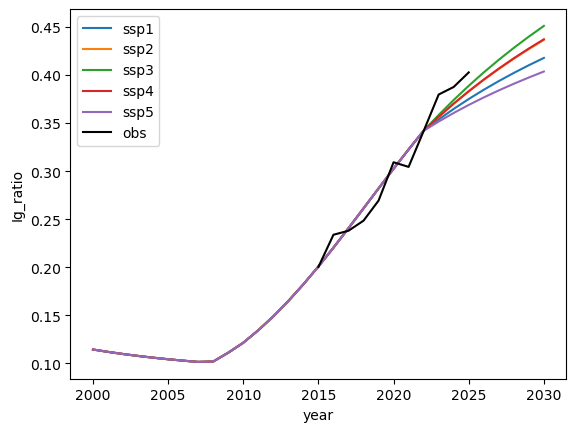

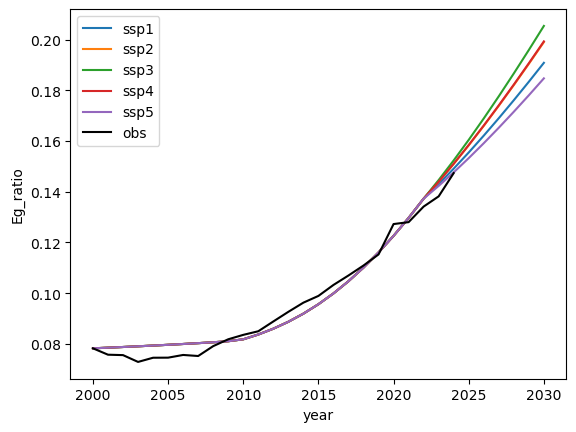

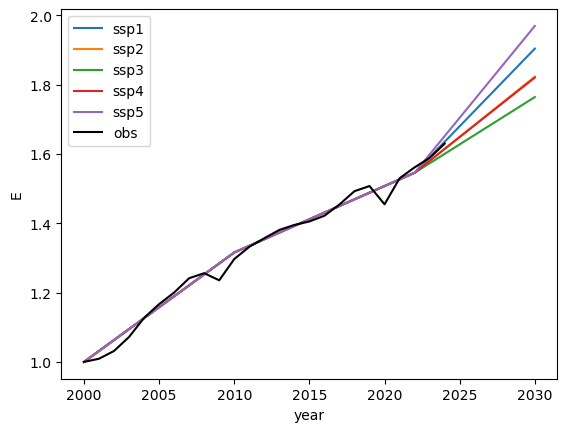

In [141]:
lef.plot_resuvsobs_ds(resu_allscen, obs2, run_names = [f'ssp{i+1}' for i in range(5)], year_ok = slice(2000, 2030))

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

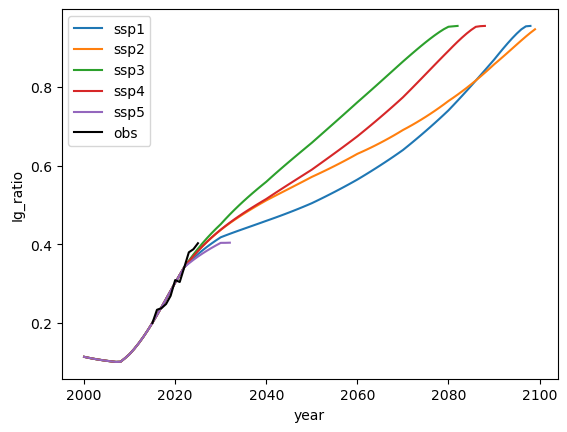

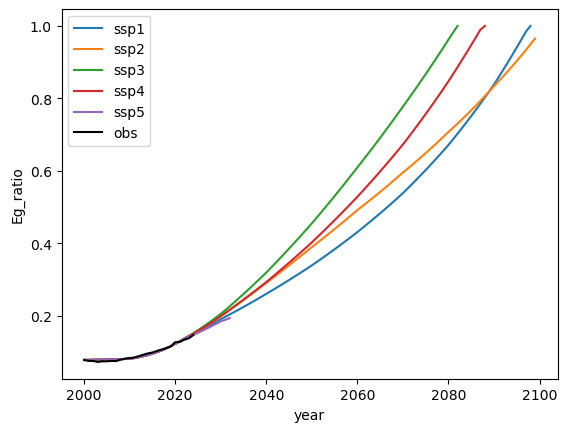

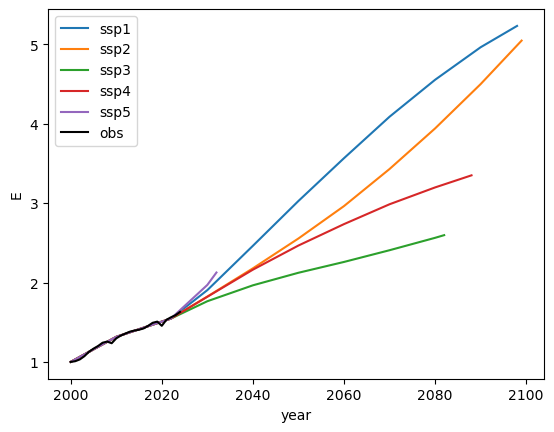

In [142]:
lef.plot_resuvsobs_ds(resu_allscen, obs2, run_names = [f'ssp{i+1}' for i in range(5)], year_ok = slice(2000, 2100))

### With growth

In [21]:
scen_growth = []

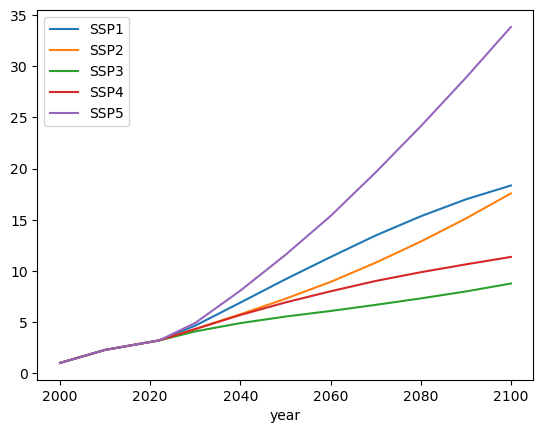

In [25]:
all_scen = []

for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    mismatch = gdp_scen[ssp].sel(year = 2022) - gdp_fit.sel(year = 2022)

    fitto = xr.concat([gdp_fit, gdp_scen[ssp].sel(year = slice(2023, None))-mismatch.values], dim = 'year')
    (fitto/fitto.sel(year = 2000)).plot(label = ssp)

    all_scen.append(fitto/fitto.sel(year = 2000))

plt.legend()

In [ ]:
scen_growth = []

for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    mismatch = gdp_scen[ssp].sel(year = 2022) - gdp_fit.sel(year = 2022)

    fitto = xr.concat([gdp_fit, gdp_scen[ssp].sel(year = slice(2023, None))-mismatch.values], dim = 'year')
    (fitto/fitto.sel(year = 2000)).plot(label = ssp)

    all_scen.append(fitto/fitto.sel(year = 2000))

plt.legend()

In [ ]:
year_ini = 2023
allresu = []

for gro in np.arange(0., 0.06, 0.01):
    params['growth'] = gro
    print('-----------------------')
    print(f'Growth = {gro}')

    # inicond_recalc = lef.inicond_yr(year_ini, params_fit, adimensional = True, fcu = lef.fossil_capacity_util)

    # resuok = lef.run_model(inicond = inicond_recalc, params = params_fit, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=scale_costs, gdp_type='custom', gdp_scenario=scen)
    # allresu.append(resuok)
    # resu = lef.run_model(inicond = lef.inicond_yr(year_ini), params = params, n_iter = 100, verbose = False, rule = 'maxgreen', year_ini = year_ini)
    # lef.plot_resu(resu, year_ini = year_ini, title = f'Growth = {gro}')
    # allresu.append(resu)

In [ ]:
gdp_fit

<xarray.DataArray (year: 23)>
array([29902.2 , 33711.6 , 37521.  , 41330.4 , 45139.8 , 48949.2 ,
       52758.6 , 56568.  , 60377.4 , 64186.8 , 67996.2 , 70309.35,
       72622.5 , 74935.65, 77248.8 , 79561.95, 81875.1 , 84188.25,
       86501.4 , 88814.55, 91127.7 , 93440.85, 95754.  ])
Coordinates:
  * year     (year) int64 2000 2001 2002 2003 2004 ... 2018 2019 2020 2021 2022

In [32]:
gdp_gro

[array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 array(49001686.79763172),
 

In [80]:
all_growths = dict()

for gro in np.arange(0., 0.06, 0.01):
    gdp_gro = []
    Y0 = gdp_fit.sel(year = 2022).values + 0.
    for i in range(2101-2023):
        Y1 = lef.GDP(Y0, growth= gro)
        gdp_gro.append(Y1)
        Y0 = Y1 + 0.

    ds = xr.DataArray(gdp_gro, coords={'year': np.arange(2023, 2101)})

    gdp_fin = xr.concat([gdp_fit, ds], dim = 'year')

    all_growths[gro] = gdp_fin


In [100]:

rainbow_palette = [
    "#D70000",  # Dark Red
    "#E56000",  # Dark Orange
    "#FFC700",  # Gold
    "#008700",  # Dark Green
    "#0057A0",  # Dark Blue
    "#4B0082"   # Indigo (Dark Purple)
]

In [ ]:
allscen

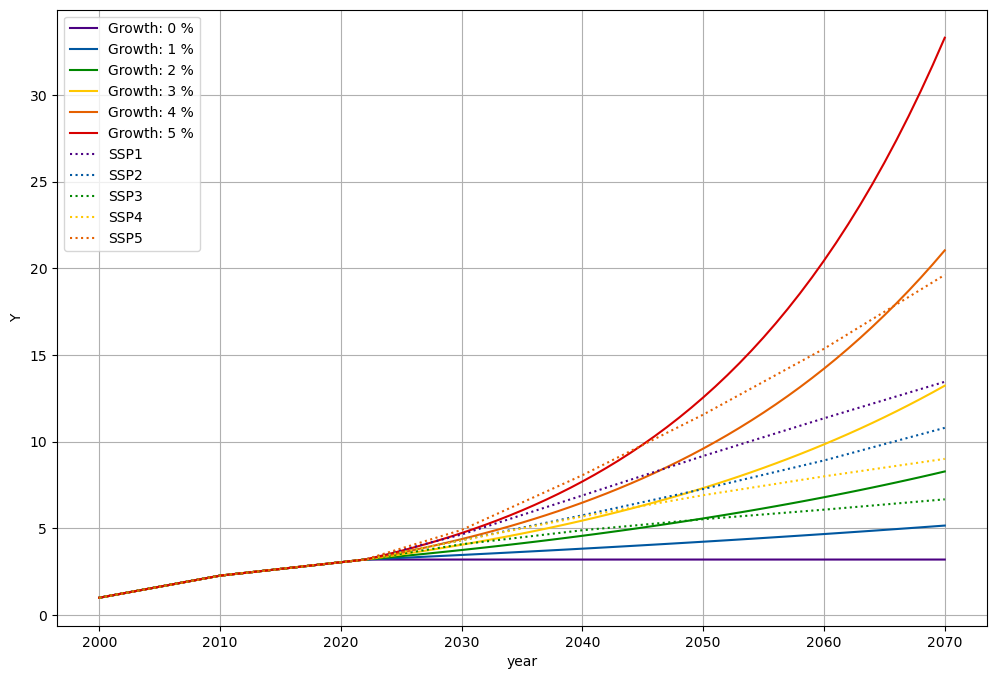

In [105]:
fig = plt.figure(figsize = (12, 8))

for gro, re, col in zip(np.arange(0., 0.06, 0.01), all_growths, rainbow_palette[::-1]):
    (all_growths[re].sel(year = slice(2000, 2070))/all_growths[re].sel(year = 2000)).plot(label = f'Growth: {int(100*gro)} %', color = col)

for i, col in zip(range(5), rainbow_palette[::-1]):
    all_scen[i].sel(year = slice(2000, 2070)).plot(label = f'SSP{i+1}', ls = ':', color = col)

plt.xlabel('year')
plt.ylabel('Y')
plt.legend()
plt.grid()

In [51]:
gdp_fit

<xarray.DataArray (year: 23)>
array([29902.2 , 33711.6 , 37521.  , 41330.4 , 45139.8 , 48949.2 ,
       52758.6 , 56568.  , 60377.4 , 64186.8 , 67996.2 , 70309.35,
       72622.5 , 74935.65, 77248.8 , 79561.95, 81875.1 , 84188.25,
       86501.4 , 88814.55, 91127.7 , 93440.85, 95754.  ])
Coordinates:
  * year     (year) int64 2000 2001 2002 2003 2004 ... 2018 2019 2020 2021 2022

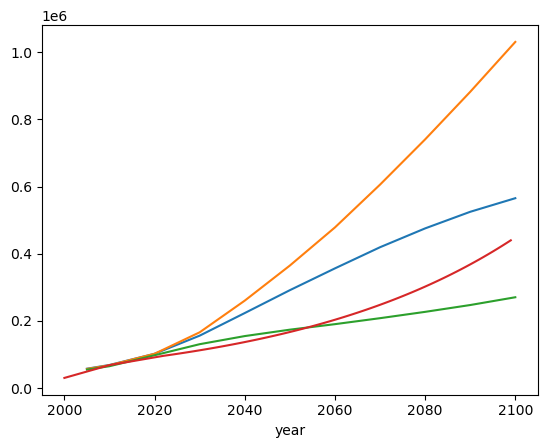

In [68]:
gdp_scen['SSP1'].plot()
gdp_scen['SSP5'].plot()
gdp_scen['SSP3'].plot()
gdp_fin.plot()

In [52]:
gdp_fin

<xarray.DataArray (year: 100)>
array([ 29902.2       ,  33711.6       ,  37521.        ,  41330.4       ,
        45139.8       ,  48949.2       ,  52758.6       ,  56568.        ,
        60377.4       ,  64186.8       ,  67996.2       ,  70309.35      ,
        72622.5       ,  74935.65      ,  77248.8       ,  79561.95      ,
        81875.1       ,  84188.25      ,  86501.4       ,  88814.55      ,
        91127.7       ,  93440.85      ,  95754.        ,  97669.08      ,
        99622.4616    , 101614.910832  , 103647.20904864, 105720.15322961,
       107834.55629421, 109991.24742009, 112191.07236849, 114434.89381586,
       116723.59169218, 119058.06352602, 121439.22479654, 123868.00929247,
       126345.36947832, 128872.27686789, 131449.72240525, 134078.71685335,
       136760.29119042, 139495.49701423, 142285.40695451, 145131.1150936 ,
       148033.73739547, 150994.41214338, 154014.30038625, 157094.58639398,
       160236.47812186, 163441.20768429, 166710.03183798, 170044.23247474,
       173445.11712423, 176914.01946672, 180452.29985605, 184061.34585317,
       187742.57277024, 191497.42422564, 195327.37271015, 199233.92016436,
       203218.59856764, 207282.970539  , 211428.62994978, 215657.20254877,
       219970.34659975, 224369.75353174, 228857.14860238, 233434.29157443,
       238102.97740591, 242865.03695403, 247722.33769311, 252676.78444697,
       257730.32013591, 262884.92653863, 268142.62506941, 273505.47757079,
       278975.58712221, 284555.09886465, 290246.20084195, 296051.12485879,
       301972.14735596, 308011.59030308, 314171.82210914, 320455.25855132,
       326864.36372235, 333401.6509968 , 340069.68401673, 346871.07769707,
       353808.49925101, 360884.66923603, 368102.36262075, 375464.40987317,
       382973.69807063, 390633.17203204, 398445.83547268, 406414.75218214,
       414543.04722578, 422833.9081703 , 431290.5863337 , 439916.39806038])
Coordinates:
  * year     (year) int64 2000 2001 2002 2003 2004 ... 2095 2096 2097 2098 2099

In [79]:
all_growths[0.]

<xarray.DataArray (year: 100)>
array([29902.2 , 33711.6 , 37521.  , 41330.4 , 45139.8 , 48949.2 ,
       52758.6 , 56568.  , 60377.4 , 64186.8 , 67996.2 , 70309.35,
       72622.5 , 74935.65, 77248.8 , 79561.95, 81875.1 , 84188.25,
       86501.4 , 88814.55, 91127.7 , 93440.85, 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  , 95754.  , 95754.  ,
       95754.  , 95754.  , 95754.  , 95754.  ])
Coordinates:
  * year     (year) int64 2000 2001 2002 2003 2004 ... 2095 2096 2097 2098 2099

In [94]:
resu_groscen = []
for gro in np.arange(0., 0.06, 0.01):
    scen = all_growths[gro]/all_growths[gro].sel(year = 2000)
    resuok = lef.run_model(inicond = inicond_recalc, params = params_fit, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=scale_costs, gdp_type='custom', gdp_scenario=scen)
    resu_groscen.append(resuok)

params:  {'growth': 0.01, 'eps': 0.24779869047245975, 'a': 0.8859051602768233, 'b': 0.7753414113290877, 'gamma_f': 0.6752910811868253, 'gamma_g': 0.6752910811868253, 'eta_g': 0.28536314759024856, 'eta_f': 0.28536314759024856, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.07846047428840937, 'beta_0': -0.02866106136893916, 'delta_sig': 0.5736877806097394, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.11     -0.66      0.08      0.92      0.01      0.44      0.00      0.03
params:  {'growth': 0.01, 'eps': 0.24779869047245975, 'a': 0.8859051602768233, 'b': 0.7753414113290877, 'gamma_f': 0.6752910811868253, 'gamma_g': 0.6752910811868253, 'eta_g': 0.28536314759024856, 'eta_f': 0.28536314759024856, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.07846047428840937, 'beta_0': -0.02866106136893916, 'delta_sig': 0.5736877806097394, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.11     -0.67      0.08      0.95      0.01      0.45      0.00 

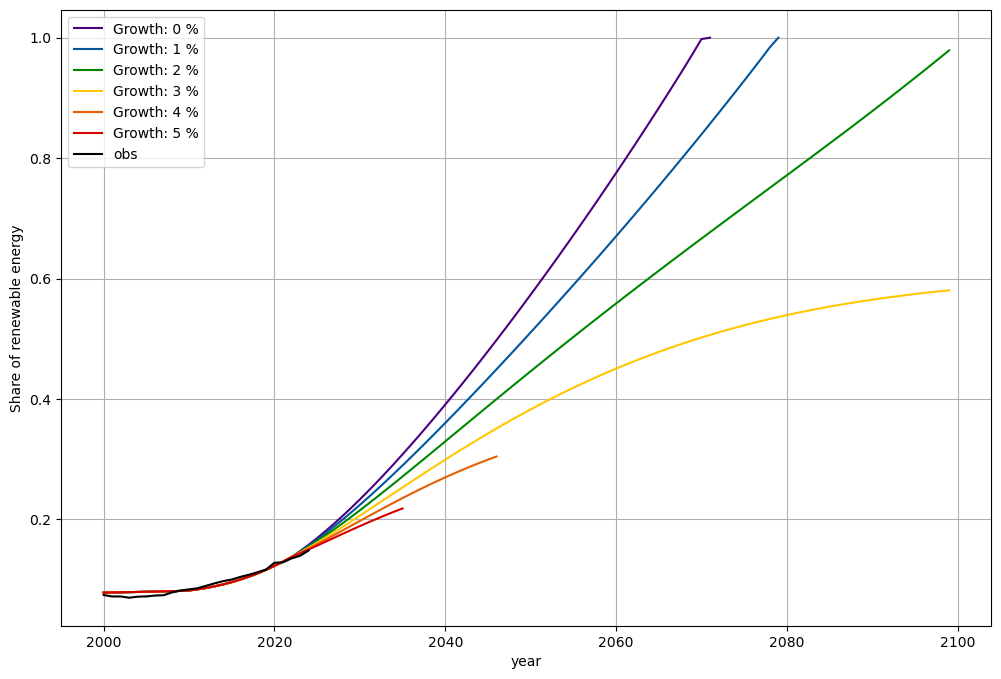

In [96]:
fig = plt.figure(figsize = (12, 8))

for gro, re, col in zip(np.arange(0., 0.06, 0.01), resu_groscen, rainbow_palette[::-1]):
    re['Eg_ratio'].plot(label = f'Growth: {int(100*gro)} %', color = col)

lef.Eg_ratio.sel(year = slice(2000, None)).plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('Share of renewable energy')
plt.legend()
plt.grid()

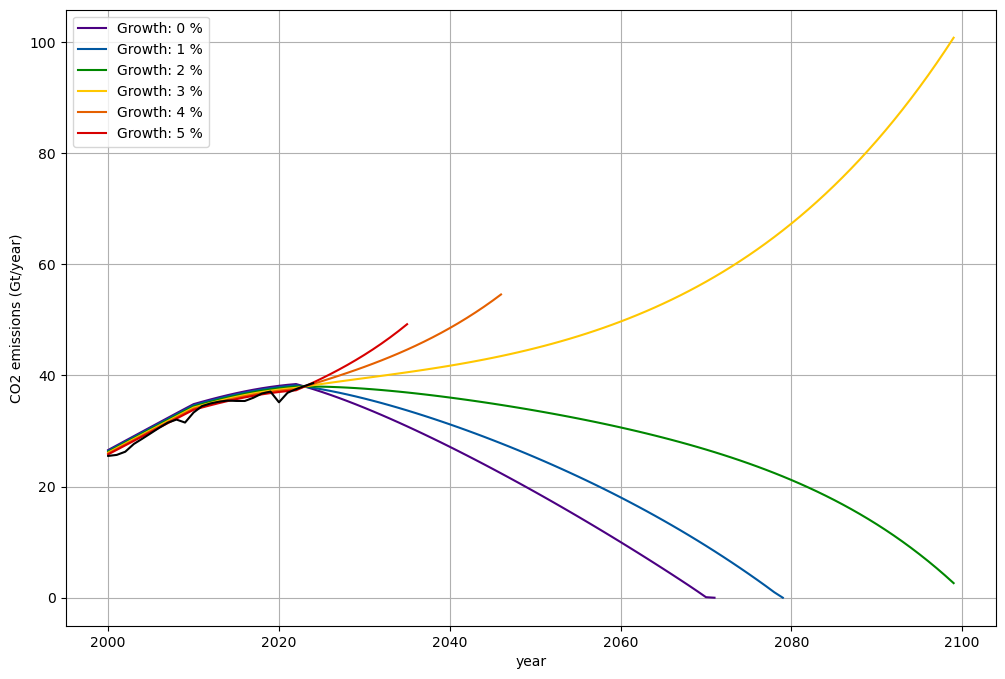

In [98]:
fig = plt.figure(figsize = (12, 8))

for gro, re, col in zip(np.arange(0., 0.06, 0.01), resu_groscen, rainbow_palette[::-1]):
    lef.to_emissions(re['Ef']).plot(label = f'Growth: {int(100*gro)} %', color = col)

# lef.to_emissions(resu_hist['Ef']).sel(year = slice(2000, 2023)).plot(color = 'grey')
lef.co2.sel(year = slice(2000, None)).plot(color = 'black')
# lef.Eg_ratio.plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('CO2 emissions (Gt/year)')
plt.legend()
plt.grid()

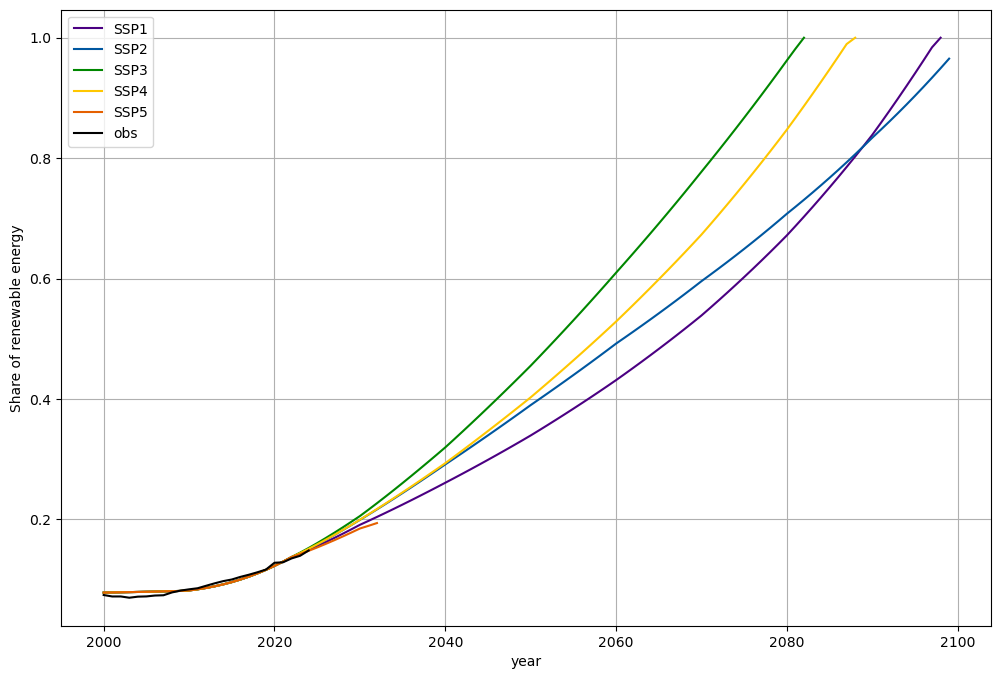

In [97]:
fig = plt.figure(figsize = (12, 8))

for ssp, re, col in zip([f'SSP{i}' for i in range(1,6)], resu_allscen, rainbow_palette[::-1]):
    re['Eg_ratio'].plot(label = ssp, color = col)

lef.Eg_ratio.sel(year = slice(2000, None)).plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('Share of renewable energy')
plt.legend()
plt.grid()

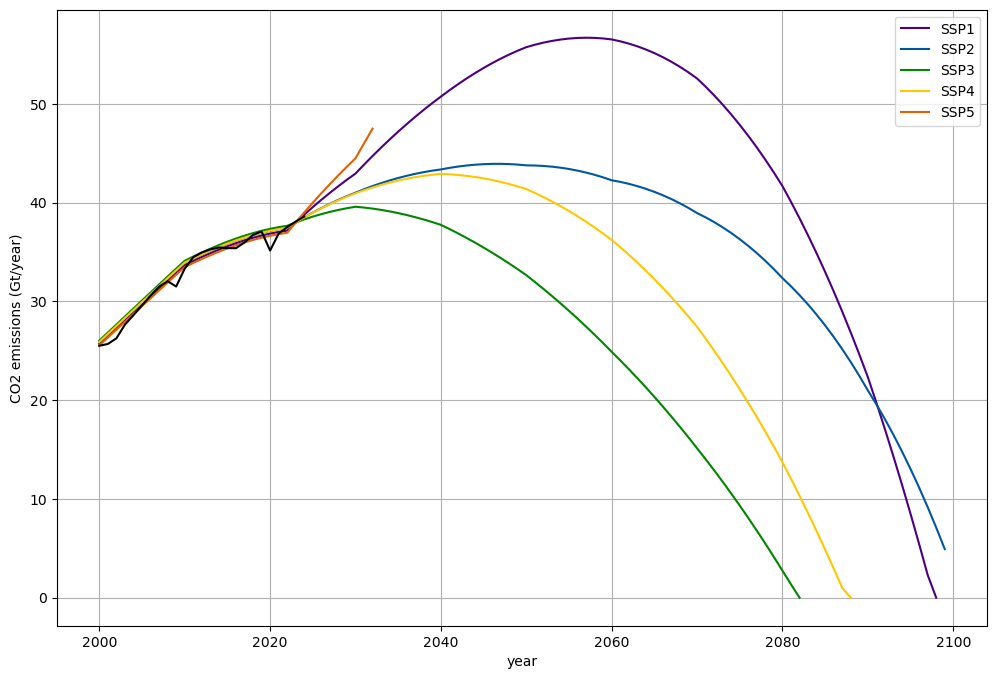

In [99]:
fig = plt.figure(figsize = (12, 8))

for ssp, re, col in zip([f'SSP{i}' for i in range(1,6)], resu_allscen, rainbow_palette[::-1]):
    lef.to_emissions(re['Ef']).plot(label = ssp, color = col)

# lef.to_emissions(resu_hist['Ef']).sel(year = slice(2000, 2023)).plot(color = 'grey')
lef.co2.sel(year = slice(2000, None)).plot(color = 'black')
# lef.Eg_ratio.plot(label = 'obs', color = 'black')

plt.xlabel('year')
plt.ylabel('CO2 emissions (Gt/year)')
plt.legend()
plt.grid()

In [107]:
import pickle

In [108]:
with open('results_neweq1_030326.p', 'wb') as filo:
    pickle.dump([resu_groscen, resu_allscen], filo)